# Estandarización de Variables con StandardScaler

Este notebook carga los datasets limpios `df_a_limpio.csv` y `df_b_limpio.csv`, aplica `StandardScaler` de scikit-learn a todas las columnas numéricas (excluyendo la columna de tiempo `timestamp`) y guarda los datasets resultantes estandarizados en la carpeta de datos procesados.

In [44]:
import os
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
df = pd.read_csv("data/processed/df_a_limpio.csv")
    
    # Identificar columna temporal
col_tiempo = 'timestamp'
if col_tiempo not in df.columns:
    col_tiempo = df.columns[0]
    df.rename(columns={col_tiempo: 'timestamp'}, inplace=True)
    col_tiempo = 'timestamp'
        
    # Separar timestamp de las variables a escalar
timestamps = df[col_tiempo]
features_df = df.drop(columns=[col_tiempo])
    
    # Identificar columnas numéricas para escalar
num_cols = features_df.select_dtypes(include=[np.number]).columns.tolist()
print(f"⚙️ Escalando {len(num_cols)} columnas numéricas: {num_cols}")
    
    # Inicializar y aplicar StandardScaler
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features_df[num_cols])
    
    # Crear DataFrame con variables escaladas
df_scaled = pd.DataFrame(features_scaled, columns=num_cols)
    
    # Volver a insertar el timestamp como primera columna
df_scaled.insert(0, col_tiempo, timestamps.reset_index(drop=True))
    
    # Guardar archivo estandarizado
    # df_scaled.to_csv(output_path, index=False)
    # print(f"💾 Guardado exitosamente en: {output_path}")
    
    # Mostrar verificación estadística rápida
mean_val = df_scaled[num_cols].mean().mean()
std_val = df_scaled[num_cols].std().mean()
print(f"📊 Verificación - Promedio general de medias: {mean_val:.4f} (debe ser ~0), Promedio de Desv. Est.: {std_val:.4f} (debe ser ~1)")
print("-" * 70)

⚙️ Escalando 15 columnas numéricas: ['x1', 'x3', 'x5', 'x6', 'x7', 'x8', 'x9', 'x10', 'y1', 'y2', 'y3', 'y4', 'y6', 'y7', 'y8']
📊 Verificación - Promedio general de medias: 0.0000 (debe ser ~0), Promedio de Desv. Est.: 1.0000 (debe ser ~1)
----------------------------------------------------------------------


In [46]:
df_scaled.head(50)

,timestamp,x1,x3,x5,x6,x7,x8,x9,x10,y1,y2,y3,y4,y6,y7,y8
0,2025-01-01 00:00:00,0.185127,-1.357045,0.002418,-0.155855,-1.473932,-0.471744,-0.977003,-1.888983,0.816996,-0.352935,0.886726,-0.011771,0.298339,-0.946757,-0.671593
1,2025-01-01 00:01:00,0.185127,-1.357045,0.146472,0.027197,-1.473932,-0.438993,-0.977017,-1.890327,0.769138,-0.337568,0.936075,-0.046730,0.310854,-0.946763,-0.680004
2,2025-01-01 00:02:00,0.185127,-1.357045,0.018861,-0.131103,-1.473932,-0.434005,-0.977032,-1.891670,0.721280,-0.347863,0.930949,-0.104937,0.280291,-0.946769,-0.688391
3,2025-01-01 00:03:00,0.185127,-1.357045,-0.136471,-0.327470,-1.473932,-0.446298,-0.977047,-1.893014,0.673422,-0.334512,0.956122,-0.153024,0.275194,-0.946774,-0.691545
4,2025-01-01 00:04:00,0.185127,-1.357045,0.024007,-0.126492,-1.473932,-0.471716,-0.977061,-1.894357,0.795097,-0.329894,0.821087,-0.117163,0.270098,-0.946780,-0.694699
5,2025-01-01 00:05:00,0.185127,-1.357045,-0.005063,-0.161493,-1.473932,-0.443410,-0.977076,-1.895701,0.710648,-0.327460,0.955406,-0.023443,0.265001,-0.946786,-0.712930
6,2025-01-01 00:06:00,0.185127,-1.357045,-0.055915,-0.225796,-1.473932,-0.471029,-0.977091,-1.897045,0.803229,-0.337010,0.863174,-0.005377,0.286383,-0.946791,-0.732815
7,2025-01-01 00:07:00,0.185127,-1.357045,-0.030387,-0.194217,-1.473932,-0.441801,-0.977105,-1.898389,0.797351,-0.364306,0.909548,-0.002636,-0.906908,-0.946797,-0.747352
8,2025-01-01 00:08:00,0.185127,-1.357045,0.137360,0.021963,-1.473932,-0.462535,-0.977120,-1.899732,0.734252,-0.366000,0.953935,-0.051666,-0.895256,-0.946802,-0.744258
9,2025-01-01 00:09:00,0.185127,-1.357045,-0.017027,-0.174548,-1.473932,-0.444942,-0.977135,-1.901076,0.673637,-0.367694,0.875510,-0.080151,-0.881058,-0.946808,-0.738896


## EVALUAR CUANTOS GRUPOS PUEDEN EXISTIR METODO DEL CODO

   ANÁLISIS DE CODO: BARRIDO DE REGÍMENES MEDIANTE CRITERIO BIC
Probando K = 2 regímenes | Valor del BIC = 11,894,824.68
Probando K = 3 regímenes | Valor del BIC = 10,096,269.96
Probando K = 4 regímenes | Valor del BIC = 8,862,620.06
Probando K = 5 regímenes | Valor del BIC = 6,056,648.76
Probando K = 6 regímenes | Valor del BIC = 4,745,753.11
Probando K = 7 regímenes | Valor del BIC = 4,402,263.70
Probando K = 8 regímenes | Valor del BIC = 3,681,464.44
Probando K = 9 regímenes | Valor del BIC = 3,189,727.78
Probando K = 10 regímenes | Valor del BIC = 3,286,739.83
💡 Conclusión Matemática: El BIC se minimiza idealmente en K = 9 grupos.
✅ Gráfica analítica guardada con éxito como 'curva_codo_bic_linea_b.png'.


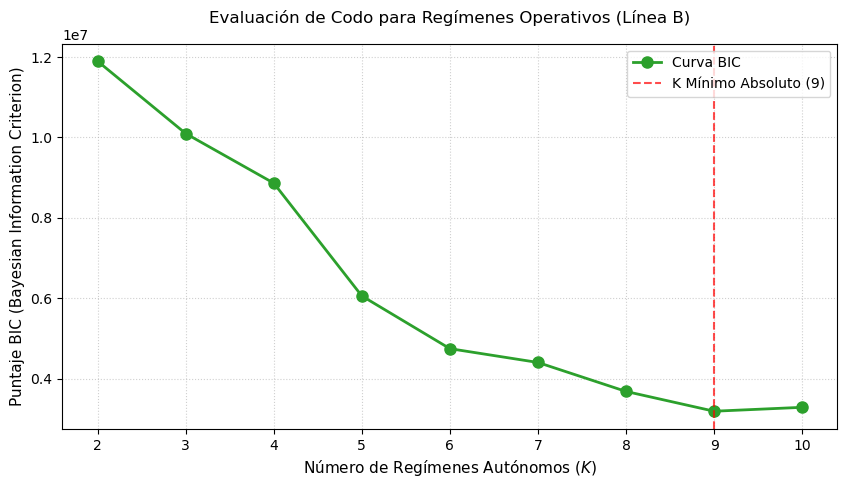

In [49]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.mixture import GaussianMixture


def evaluar_codo_gmm_bic_industrial(df_escalado, max_clusters=8):
    """Realiza la evaluación de codo con el criterio BIC, asegurando

    que el timestamp sea excluido de los cálculos matemáticos del GMM.
    """
    # --- CAPA DE SEGURIDAD PARA SERIES DE TIEMPO ---
    # Creamos una copia local para no alterar tu dataframe original
    df_analisis = df_escalado.copy()

    # Si el timestamp está en las columnas, lo pasamos al índice
    if "timestamp" in df_analisis.columns:
        df_analisis["timestamp"] = pd.to_datetime(df_analisis["timestamp"])
        df_analisis.set_index("timestamp", inplace=True)
    # Por si acaso la columna viene sin nombre en formato string (Unnamed: 0)
    elif "Unnamed: 0" in df_analisis.columns:
        df_analisis.rename(
            columns={"Unnamed: 0": "timestamp"}, inplace=True
        )
        df_analisis["timestamp"] = pd.to_datetime(df_analisis["timestamp"])
        df_analisis.set_index("timestamp", inplace=True)

    # El rango de componentes a evaluar (de 2 al máximo deseado)
    n_componentes = range(2, max_clusters + 1)
    valores_bic = []

    print("=" * 70)
    print("   ANÁLISIS DE CODO: BARRIDO DE REGÍMENES MEDIANTE CRITERIO BIC")
    print("=" * 70)

    # Corremos el bucle de entrenamiento probabilístico
    for k in n_componentes:
        gmm = GaussianMixture(
            n_components=k,
            random_state=42,
            covariance_type="full",  # Permite orientar libremente los elipsoides
            max_iter=100,
        )

        # ¡AHORA SÍ! 'df_analisis' contiene exclusivamente datos float64 puros
        gmm.fit(df_analisis)

        bic = gmm.bic(df_analisis)
        valores_bic.append(bic)

        print(f"Probando K = {k} regímenes | Valor del BIC = {bic:,.2f}")

    print("=" * 70)

    # Identificación del codo u óptimo absoluto
    indice_optimo = np.argmin(valores_bic)
    k_sugerido = n_componentes[indice_optimo]
    print(
        f"💡 Conclusión Matemática: El BIC se minimiza idealmente en K = {k_sugerido} grupos."
    )

    # --- GENERACIÓN DE LA GRÁFICA DEL CODO ---
    fig, ax = plt.subplots(figsize=(10, 5))

    ax.plot(
        n_componentes,
        valores_bic,
        marker="o",
        linestyle="-",
        color="#2ca02c",
        linewidth=2,
        markersize=8,
        label="Curva BIC",
    )
    ax.axvline(
        x=k_sugerido,
        color="red",
        linestyle="--",
        alpha=0.7,
        label=f"K Mínimo Absoluto ({k_sugerido})",
    )

    ax.set_title(
        "Evaluación de Codo para Regímenes Operativos (Línea B)",
        fontsize=12,
        pad=15,
    )
    ax.set_xlabel("Número de Regímenes Autónomos ($K$)", fontsize=11)
    ax.set_ylabel("Puntaje BIC (Bayesian Information Criterion)", fontsize=11)
    ax.set_xticks(n_componentes)
    ax.grid(True, linestyle=":", alpha=0.6)
    ax.legend(loc="upper right")

    fig.savefig("curva_codo_bic_linea_b.png", dpi=300, bbox_inches="tight")
    print(
        "✅ Gráfica analítica guardada con éxito como 'curva_codo_bic_linea_b.png'."
    )

    return k_sugerido, valores_bic


# =====================================================================
# LLAMADA CORREGIDA EN TU SCRIPT (Línea 94)
# =====================================================================
# Ejecuta la función modificada pasándole tu dataframe 'df_scaled'
k_ganador, historial_bic = evaluar_codo_gmm_bic_industrial(
    df_scaled, max_clusters=10
)

## AGRUPAMIENTO

In [52]:
import numpy as np
import pandas as pd
from sklearn.mixture import GaussianMixture
csv_path="data/processed/df_a_limpio.csv"
df_limpio = pd.read_csv(csv_path, index_col=0, parse_dates=True)

# --- Asegurar limpieza de la matriz de entrada ---
# 'df_scaled' es tu matriz estandarizada (z-scores)
df_analisis = df_scaled.copy()
if "timestamp" in df_analisis.columns:
    df_analisis.set_index("timestamp", inplace=True)
elif "Unnamed: 0" in df_analisis.columns:
    df_analisis.rename(columns={"Unnamed: 0": "timestamp"}, inplace=True)
    df_analisis.set_index("timestamp", inplace=True)

# Lista de configuraciones a evaluar
valores_k = [4, 5]
metricas_gmm = []
perfiles_por_k = {}

print("=" * 80)
print("       EVALUACIÓN DE MÉTRICAS MATEMÁTICAS: GMM (K=4 vs K=5)")
print("=" * 80)



for k in valores_k:
    # 1. Inicializar y entrenar el modelo GMM
    gmm = GaussianMixture(
        n_components=k, random_state=42, covariance_type="full", max_iter=150
    )
    gmm.fit(df_analisis)

    # 2. Extracción de métricas probabilísticas
    bic_val = gmm.bic(df_analisis)
    aic_val = gmm.aic(df_analisis)
    log_lh = gmm.score(
        df_analisis
    )  # Log-likelihood promedio por muestra (fórmula estadística)

    metricas_gmm.append(
        {"K (Grupos)": k, "BIC": bic_val, "AIC": aic_val, "Log-Likelihood": log_lh}
    )

    # 3. Asignar etiquetas al dataset original con UNIDADES REALES (df_limpio)
    etiquetas = gmm.predict(df_analisis)
    col_name = f"Regimen_K{k}"
    df_limpio[col_name] = etiquetas

    # 4. Calcular perfiles promedio del proceso en unidades de ingeniería
    perfiles_por_k[k] = df_limpio.groupby(col_name).mean()

# --- MOSTRAR TABLA COMPARATIVA DE MÉTRICAS ---
df_metricas = pd.DataFrame(metricas_gmm)
print(
    df_metricas.to_string(
        index=False,
        formatters={
            "BIC": "{:,.2f}".format,
            "AIC": "{:,.2f}".format,
            "Log-Likelihood": "{:.4f}".format,
        },
    )
)
print("=" * 80)


# --- MOSTRAR LOS PERFILES REALES DE PLANTA PARA COMPARACIÓN OPERATIVA ---
print("\n" + "#" * 80)
print("         ANÁLISIS COMPARATIVO DE SIGNUFICADO OPERATIVO (VALORES REALES)")
print("#" * 80)

for k in valores_k:
    print(f"\n📊 PERFIL PROMEDIO DE VARIABLES CON K = {k} REGÍMENES:")
    print("-" * 60)
    # Transponemos la tabla para comparar las variables (filas) contra los grupos (columnas)
    tabla_perfil = perfiles_por_k[k].T

    # Filtramos columnas de control de regímenes para no ensuciar la visualización
    columnas_variables = [
        c for c in tabla_perfil.index if not c.startswith("Regimen_")
    ]
    print(tabla_perfil.loc[columnas_variables].round(2))
    print("-" * 60)

# Guardar el dataset con ambas propuestas de etiquetas para tu análisis visual
df_limpio.to_csv("linea_b_evaluacion_k4_k5.csv")
print("\n💾 Resultados exportados a 'linea_b_evaluacion_k4_k5.csv'")

       EVALUACIÓN DE MÉTRICAS MATEMÁTICAS: GMM (K=4 vs K=5)
 K (Grupos)          BIC          AIC Log-Likelihood
          4 8,862,620.06 8,856,554.52        -8.4400
          5 6,056,648.76 6,049,064.05        -5.7640

################################################################################
         ANÁLISIS COMPARATIVO DE SIGNUFICADO OPERATIVO (VALORES REALES)
################################################################################

📊 PERFIL PROMEDIO DE VARIABLES CON K = 4 REGÍMENES:
------------------------------------------------------------
Regimen_K4        0        1        2        3
x1            31.98    33.57    32.45    33.55
x3            61.73    64.67    63.59    59.88
x5            57.35    59.70    58.15    35.40
x6          1535.83  1532.68  1460.92   789.64
x7            34.61    30.85    27.75    33.46
x8             0.49     0.36     0.45     0.20
x9            18.47    58.64    40.80    63.89
x10           83.88    91.71    75.47    88.75
y1       

## MAXIMOS Y MINIMOS DE VARIABLES

In [53]:
csv_path="linea_b_evaluacion_k4_k5.csv"
df_agrupado = pd.read_csv(csv_path, index_col=0, parse_dates=True)

In [54]:
import pandas as pd
# 1. Cargar el dataset
file_path = "linea_b_evaluacion_k4_k5.csv"
df = pd.read_csv(file_path)
# 2. Identificar columnas numéricas de interés (excluyendo fechas y los regímenes)
cols_variables = [
    col for col in df.columns 
    if col not in ["timestamp", "Unnamed: 0", "Regimen_K4", "Regimen_K5"]
]
# 3. Análisis agrupado por Regimen_K4
print("=" * 80)
print("MÍNIMOS Y MÁXIMOS AGRUPADOS POR REGIMEN_K4")
print("=" * 80)
resumen_k4 = df.groupby("Regimen_K4")[cols_variables].agg(["min", "max"])
# Transponemos (.T) para que la tabla sea más fácil de leer verticalmente
print(resumen_k4.T)
# 4. Análisis agrupado por Regimen_K5
print("\n" + "=" * 80)
print("MÍNIMOS Y MÁXIMOS AGRUPADOS POR REGIMEN_K5")
print("=" * 80)
resumen_k5 = df.groupby("Regimen_K5")[cols_variables].agg(["min", "max"])
print(resumen_k5.T)

MÍNIMOS Y MÁXIMOS AGRUPADOS POR REGIMEN_K4
Regimen_K4            0            1            2            3
x1  min        0.010930    19.000244    14.025624     0.000000
    max       59.991455    59.517971    64.996338    64.727798
x3  min        0.000000    57.049267    44.834579     0.000000
    max       69.995117    69.995117    70.001221    79.981842
x5  min        0.000000    44.783409    42.531834     0.000000
    max      100.000000    77.630646    79.737209    99.938454
x6  min        0.000000   840.226054   736.852482     0.000000
    max     5000.000000  2357.365381  2458.587119  3713.194092
x7  min        0.000000     0.000000     0.000000     0.000000
    max      100.000000   100.000000    88.083694   100.000000
x8  min        0.000000     0.000000     0.000042     0.000000
    max        1.590000     1.409960     1.859308     1.513897
x9  min        0.000000     0.000000     0.000000     0.000000
    max      100.000000   100.000000   100.000000   100.000000
x10 min     